In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
# 1. Load Dataset
df = pd.read_csv('/content/drive/MyDrive/Cleaned_dataset.csv')
df.head()

,Order_Hour,Day_of_Week,Is_Weekend,Is_Festival,Weather,Pickup_Zone,Dropoff_Zone,Vehicle_Type,Rider_Experience_Years,Rider_Rating,...,Order_Items,Restaurant_Load,Preparation_Time_Min,Road_Distance_km,Delivery_Distance_Category,Traffic_Level,Number_of_Signals,Average_Speed_kmph,Delivery_Priority,Time_taken_min
0,8,Tuesday,0,0,Clear,CBD,Commercial,Scooter,3.1,3.8,...,1,Medium,23,30.55,Long,Moderate,15,28.7,Normal,91
1,12,Friday,0,0,Rain,CBD,CBD,Scooter,1.8,3.6,...,3,Medium,11,2.25,Short,Moderate,17,23.3,Normal,21
2,18,Sunday,1,0,Clear,Residential,Residential,Scooter,3.8,3.9,...,1,Low,31,10.15,Long,Moderate,8,28.9,Normal,52
3,12,Wednesday,0,0,Cloudy,Residential,Industrial,Bike,1.7,3.9,...,3,Medium,19,26.33,Long,Low,9,41.4,Normal,59
4,18,Monday,0,0,Rain,Industrial,Residential,Bike,12.4,4.4,...,1,Medium,7,30.48,Long,Moderate,8,31.7,Normal,75


In [ ]:
# Selecting Dependent and Independent Variables
X = df.drop(["Time_taken_min",'Average_Speed_kmph'], axis=1)
y = df["Time_taken_min"]

In [ ]:
# 3. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [ ]:
# 4. Define Feature Groups

nominal_col = [
    'Day_of_Week',
    'Weather',
    'Pickup_Zone',
    'Dropoff_Zone',
    'Vehicle_Type',
    'Cuisine_Type'
]

ordinal_col = [
    'Restaurant_Load',
    'Delivery_Distance_Category',
    'Traffic_Level',
    'Delivery_Priority'
]


# Numerical columns
num_cols = X_train.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

print("Numerical:", num_cols)
print("Nominal:", nominal_col)
print("Ordinal:", ordinal_col)


Numerical: ['Order_Hour', 'Is_Weekend', 'Is_Festival', 'Rider_Experience_Years', 'Rider_Rating', 'Restaurant_Rating', 'Order_Items', 'Preparation_Time_Min', 'Road_Distance_km', 'Number_of_Signals']
Nominal: ['Day_of_Week', 'Weather', 'Pickup_Zone', 'Dropoff_Zone', 'Vehicle_Type', 'Cuisine_Type']
Ordinal: ['Restaurant_Load', 'Delivery_Distance_Category', 'Traffic_Level', 'Delivery_Priority']


In [ ]:

# 5. Numerical Pipeline

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean'))
])


In [ ]:
nominal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

In [ ]:
# 7. Ordinal Pipeline

ordinal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(
        categories=[
            ['Low', 'Medium', 'High'],
            ['Short', 'Medium', 'Long'],
            ['Low', 'Moderate', 'High', 'Severe'],
            ['Normal', 'Priority', 'VIP']
        ],
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ))
])

In [ ]:
# 8. Column Transformer

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_cols),
        ('nominal', nominal_pipeline, nominal_col),
        ('ordinal', ordinal_pipeline, ordinal_col)
    ],
    remainder='drop'
)

In [ ]:
# 9. Linear Regression Model

model = LinearRegression()

In [ ]:
# 10. Complete Pipeline

pipe = Pipeline([
    ('Preprocessor', preprocessor),
    ('model', model)
])


In [ ]:
# 11. Train Model

pipe.fit(X_train, y_train)

Pipeline(steps=[('Preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer())]),
                                                  ['Order_Hour', 'Is_Weekend',
                                                   'Is_Festival',
                                                   'Rider_Experience_Years',
                                                   'Rider_Rating',
                                                   'Restaurant_Rating',
                                                   'Order_Items',
                                                   'Preparation_Time_Min',
                                                   'Road_Distance_km',
                                                   'Number_of_Signals']),
                                                 ('nominal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(st...
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OrdinalEncoder(categories=[['Low',
                                                                                               'Medium',
                                                                                               'High'],
                                                                                              ['Short',
                                                                                               'Medium',
                                                                                               'Long'],
                                                                                              ['Low',
                                                                                               'Moderate',
                                                                                               'High',
                                                                                               'Severe'],
                                                                                              ['Normal',
                                                                                               'Priority',
                                                                                               'VIP']],
                                                                                  handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  ['Restaurant_Load',
                                                   'Delivery_Distance_Category',
                                                   'Traffic_Level',
                                                   'Delivery_Priority'])])),
                ('model', LinearRegression())])

In [ ]:
# 12. Prediction

y_pred = pipe.predict(X_test)

In [ ]:
# 13. Evaluation

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2score = r2_score(y_test, y_pred)


print("\nLinear Regression Results")
print("------------------------")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2  :", r2score)


Linear Regression Results
------------------------
MAE : 6.493325837798736
MSE : 86.88416567687247
RMSE: 9.321167613387953
R2  : 0.9315998373528601


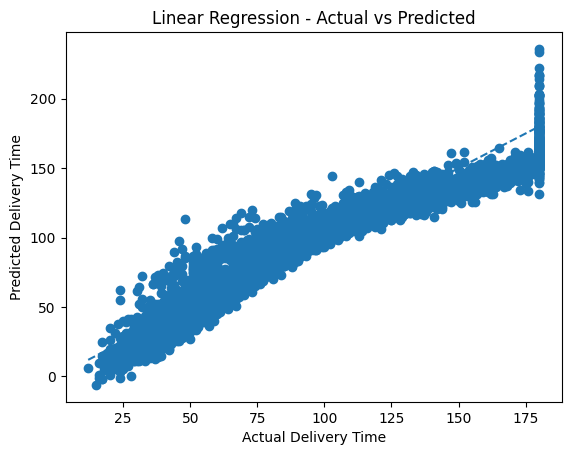

In [ ]:
plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Delivery Time")
plt.ylabel("Predicted Delivery Time")
plt.title("Linear Regression - Actual vs Predicted")

plt.show()

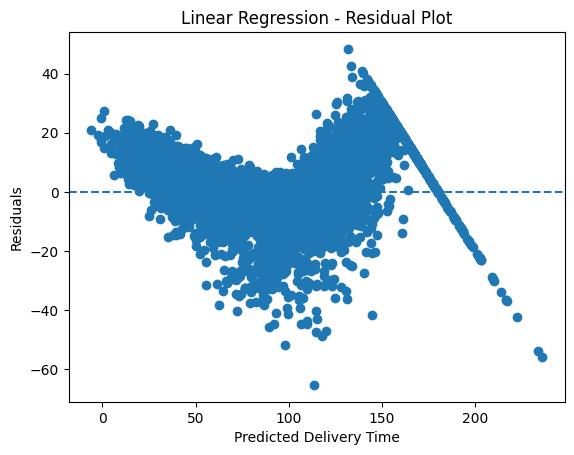

In [ ]:
residual = y_test - y_pred

plt.scatter(y_pred, residual)

plt.axhline(0, linestyle="--")

plt.xlabel("Predicted Delivery Time")
plt.ylabel("Residuals")
plt.title("Linear Regression - Residual Plot")

plt.show()

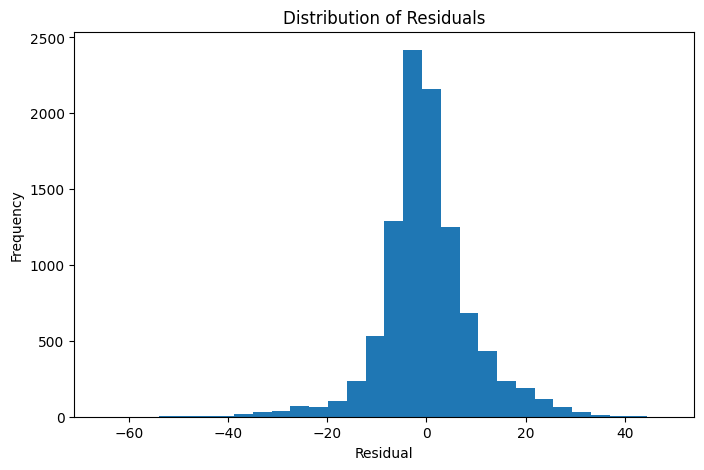

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(
    residual,
    bins=30
)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")

plt.show()

In [ ]:
# Transform training data using the fitted preprocessor
X_train_transformed = preprocessor.transform(X_train)

# Convert to dense array if necessary
if hasattr(X_train_transformed, "toarray"):
    X_train_transformed = X_train_transformed.toarray()

# Get feature names
feature_names = preprocessor.get_feature_names_out()

# Create DataFrame
X_vif = pd.DataFrame(
    X_train_transformed,
    columns=feature_names
)

X_vif.head()

,num__Order_Hour,num__Is_Weekend,num__Is_Festival,num__Rider_Experience_Years,num__Rider_Rating,num__Restaurant_Rating,num__Order_Items,num__Preparation_Time_Min,num__Road_Distance_km,num__Number_of_Signals,...,nominal__Cuisine_Type_Cafe,nominal__Cuisine_Type_Chinese,nominal__Cuisine_Type_Desserts,nominal__Cuisine_Type_North Indian,nominal__Cuisine_Type_Pizza,nominal__Cuisine_Type_South Indian,ordinal__Restaurant_Load,ordinal__Delivery_Distance_Category,ordinal__Traffic_Level,ordinal__Delivery_Priority
0,21.0,1.0,0.0,4.1,3.5,3.7,4.0,16.0,24.08,9.0,...,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,2.0,0.0
1,14.0,0.0,0.0,6.3,4.5,3.3,1.0,30.0,20.00,6.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,0.0,1.0
2,13.0,0.0,0.0,7.2,4.0,4.0,3.0,30.0,22.24,2.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,2.0,0.0,0.0
3,11.0,0.0,0.0,5.7,4.3,4.0,2.0,27.0,16.22,8.0,...,0.0,0.0,0.0,1.0,0.0,0.0,2.0,2.0,0.0,0.0
4,20.0,0.0,0.0,6.1,3.8,5.0,1.0,30.0,33.69,6.0,...,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,0.0,0.0


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()

vif_data["Feature"] = X_vif.columns

vif_data["VIF"] = [
    variance_inflation_factor(
        X_vif.values,
        i
    )
    for i in range(X_vif.shape[1])
]

vif_data = vif_data.sort_values(
    by="VIF",
    ascending=False
)

print(vif_data)

/tmp/ipykernel_2627/2801430365.py:8: UserWarning: The design matrix is poorly conditioned (condition number=1.14e+16). VIF calculations may be numerically unstable.
  variance_inflation_factor(
/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatri

                                   Feature           VIF
1                          num__Is_Weekend  1.000800e+15
13             nominal__Day_of_Week_Sunday  1.000800e+15
16          nominal__Day_of_Week_Wednesday  1.000800e+15
14           nominal__Day_of_Week_Thursday  1.000800e+15
15            nominal__Day_of_Week_Tuesday  1.000800e+15
11             nominal__Day_of_Week_Monday  1.000800e+15
12           nominal__Day_of_Week_Saturday  1.000800e+15
10             nominal__Day_of_Week_Friday  1.000800e+15
25        nominal__Pickup_Zone_Residential  1.000800e+15
24         nominal__Pickup_Zone_Industrial  1.000800e+15
23         nominal__Pickup_Zone_Commercial  1.000800e+15
22                nominal__Pickup_Zone_CBD  1.000800e+15
21                  nominal__Weather_Storm  1.000800e+15
20                   nominal__Weather_Rain  1.000800e+15
19                    nominal__Weather_Fog  1.000800e+15
18                 nominal__Weather_Cloudy  1.000800e+15
17                  nominal__We

/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared


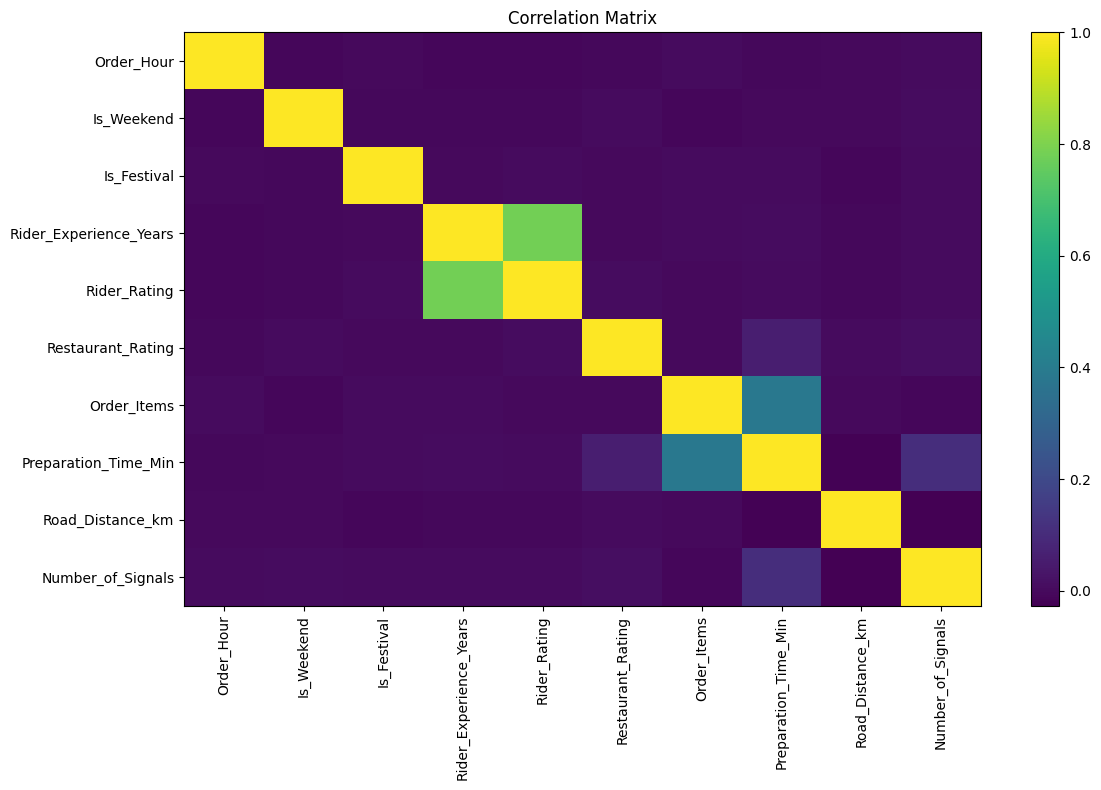

In [ ]:
numeric_data = X_train.select_dtypes(
    include=['int64', 'float64']
)

correlation = numeric_data.corr()

plt.figure(figsize=(12, 8))

plt.imshow(
    correlation,
    aspect='auto'
)

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.show()

In [ ]:
corr_pairs = (
    correlation
    .where(np.triu(np.ones(correlation.shape), k=1).astype(bool))
    .stack()
    .sort_values(ascending=False)
)

print(corr_pairs.head(15))

Rider_Experience_Years  Rider_Rating            0.782609
Order_Items             Preparation_Time_Min    0.383762
Preparation_Time_Min    Number_of_Signals       0.107474
Restaurant_Rating       Preparation_Time_Min    0.058411
                        Number_of_Signals       0.012603
Rider_Rating            Restaurant_Rating       0.006277
Is_Weekend              Number_of_Signals       0.005817
Rider_Experience_Years  Preparation_Time_Min    0.005421
Order_Hour              Number_of_Signals       0.005136
Rider_Rating            Preparation_Time_Min    0.004561
                        Number_of_Signals       0.004529
Is_Festival             Number_of_Signals       0.004512
Restaurant_Rating       Road_Distance_km        0.004417
Is_Weekend              Restaurant_Rating       0.004111
Rider_Experience_Years  Order_Items             0.002277
dtype: float64


In [ ]:
residual_analysis = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred,
    "Residual": residual,
    "Absolute_Error": abs(residual)
})

residual_analysis = residual_analysis.sort_values(
    by="Absolute_Error",
    ascending=False
)

print(residual_analysis.head(10))

       Actual   Predicted   Residual  Absolute_Error
42127      48  113.319297 -65.319297       65.319297
11313     180  235.838373 -55.838373       55.838373
43935     180  233.773035 -53.773035       53.773035
39303      46   97.774006 -51.774006       51.774006
30922      69  117.622113 -48.622113       48.622113
16033     180  131.645134  48.354866       48.354866
32329      67  114.393807 -47.393807       47.393807
37595      73  119.993256 -46.993256       46.993256
18124      44   89.654483 -45.654483       45.654483
44355      47   91.846807 -44.846807       44.846807


In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

In [ ]:
ridge_model = Ridge()

In [ ]:
ridge_pipe = Pipeline([
    ('Preprocessor', preprocessor),
    ('model', ridge_model)
])


In [ ]:
param_grid = {
    'model__alpha': [
        0.001,
        0.01,
        0.1,
        1,
        10,
        100,
        1000
    ]
}

In [ ]:
ridge_search = GridSearchCV(
    estimator=ridge_pipe,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

ridge_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('Preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer())]),
                                                                         ['Order_Hour',
                                                                          'Is_Weekend',
                                                                          'Is_Festival',
                                                                          'Rider_Experience_Years',
                                                                          'Rider_Rating',
                                                                          'Restaurant_Rating',
                                                                          'Order_Items',
                                                                          'Preparation_Time_Min',
                                                                          'Road_Distance_km',
                                                                          'Number_of_Signals']),
                                                                        ('nominal',
                                                                         Pipeline(steps=...
                                                                                                                      'Medium',
                                                                                                                      'High'],
                                                                                                                     ['Short',
                                                                                                                      'Medium',
                                                                                                                      'Long'],
                                                                                                                     ['Low',
                                                                                                                      'Moderate',
                                                                                                                      'High',
                                                                                                                      'Severe'],
                                                                                                                     ['Normal',
                                                                                                                      'Priority',
                                                                                                                      'VIP']],
                                                                                                         handle_unknown='use_encoded_value',
                                                                                                         unknown_value=-1))]),
                                                                         ['Restaurant_Load',
                                                                          'Delivery_Distance_Category',
                                                                          'Traffic_Level',
                                                                          'Delivery_Priority'])])),
                                       ('model', Ridge())]),
             n_jobs=-1,
             param_grid={'model__alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]},
             scoring='r2')

In [ ]:
print("Best Alpha:")
print(ridge_search.best_params_)

print("\nBest CV Score:")
print(ridge_search.best_score_)

Best Alpha:
{'model__alpha': 1}

Best CV Score:
0.9308213422023973


In [ ]:
best_ridge = ridge_search.best_estimator_

y_pred_ridge = best_ridge.predict(X_test)

mae_ridge = mean_absolute_error(
    y_test,
    y_pred_ridge
)

mse_ridge = mean_squared_error(
    y_test,
    y_pred_ridge
)

rmse_ridge = np.sqrt(mse_ridge)

r2_ridge = r2_score(
    y_test,
    y_pred_ridge
)

print("\nRidge Regression Results")
print("------------------------")
print("MAE :", mae_ridge)
print("MSE :", mse_ridge)
print("RMSE:", rmse_ridge)
print("R2  :", r2_ridge)


Ridge Regression Results
------------------------
MAE : 6.493478867901675
MSE : 86.88363826845853
RMSE: 9.321139322446507
R2  : 0.9316002525587956


In [ ]:
print("\nLinear Regression vs Ridge Regression")

print("\nMAE")
print("Linear:", mae)
print("Ridge :", mae_ridge)

print("\nRMSE")
print("Linear:", rmse)
print("Ridge :", rmse_ridge)

print("\nR2")
print("Linear:", r2score)
print("Ridge :", r2_ridge)


Linear Regression vs Ridge Regression

MAE
Linear: 6.493325837798736
Ridge : 6.493478867901675

RMSE
Linear: 9.321167613387953
Ridge : 9.321139322446507

R2
Linear: 0.9315998373528601
Ridge : 0.9316002525587956


In [ ]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV

# 1. Create Lasso model
lasso_model = Lasso(max_iter=10000)

# 2. Create Pipeline
lasso_pipe = Pipeline([
    ('Preprocessor', preprocessor),
    ('model', lasso_model)
])

# 3. Define alpha values
param_grid_lasso = {
    'model__alpha': [
        0.0001,
        0.001,
        0.01,
        0.1,
        1,
        10,
        100
    ]
}

# 4. Grid Search
lasso_search = GridSearchCV(
    estimator=lasso_pipe,
    param_grid=param_grid_lasso,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# 5. Train
lasso_search.fit(X_train, y_train)

# 6. Best parameters
print("Best Alpha:")
print(lasso_search.best_params_)

print("\nBest CV Score:")
print(lasso_search.best_score_)

Best Alpha:
{'model__alpha': 0.01}

Best CV Score:
0.9308439418860971


In [ ]:
# Best Lasso model
best_lasso = lasso_search.best_estimator_

# Prediction
y_pred_lasso = best_lasso.predict(X_test)

# Evaluation
mae_lasso = mean_absolute_error(
    y_test,
    y_pred_lasso
)

mse_lasso = mean_squared_error(
    y_test,
    y_pred_lasso
)

rmse_lasso = np.sqrt(mse_lasso)

r2_lasso = r2_score(
    y_test,
    y_pred_lasso
)

print("\nLasso Regression Results")
print("-----------------------")
print("MAE :", mae_lasso)
print("MSE :", mse_lasso)
print("RMSE:", rmse_lasso)
print("R2  :", r2_lasso)


Lasso Regression Results
-----------------------
MAE : 6.49061171628059
MSE : 86.8326132812636
RMSE: 9.318401863048384
R2  : 0.9316404223342203


In [ ]:
print("\nModel Comparison")
print("----------------")

print("\nMAE")
print("Linear:", mae)
print("Ridge :", mae_ridge)
print("Lasso :", mae_lasso)

print("\nRMSE")
print("Linear:", rmse)
print("Ridge :", rmse_ridge)
print("Lasso :", rmse_lasso)

print("\nR2")
print("Linear:", r2score)
print("Ridge :", r2_ridge)
print("Lasso :", r2_lasso)


Model Comparison
----------------

MAE
Linear: 6.493325837798736
Ridge : 6.493478867901675
Lasso : 6.49061171628059

RMSE
Linear: 9.321167613387953
Ridge : 9.321139322446507
Lasso : 9.318401863048384

R2
Linear: 0.9315998373528601
Ridge : 0.9316002525587956
Lasso : 0.9316404223342203


- All three models are giving almost similar results.
- The MAE is around 6.49 minutes, so the predictions are off by about 6–7 minutes on average.
- The RMSE is around 9.32 minutes, which shows there are some larger prediction errors.
- The R² score is around 93%, so the models are able to explain most of the variation in delivery time.
- Lasso Regression performed slightly better than Linear and Ridge Regression.
- The difference between the three models is very small.
- Ridge Regression did not show much improvement over Linear Regression.
- Overall, these models are giving good results for the delivery time prediction.
- I will compare these results with Decision Tree, Random Forest, and other advanced models to find whether the performance can be improved.